# Analisis Kualitas Udara Kabupaten Sampang

**Pertemuan 1 — Business Understanding, Data Understanding, Data Collection, dan Eksplorasi Awal**

Notebook ini mendokumentasikan proses pengamatan kualitas udara di Kabupaten Sampang menggunakan data Sentinel-5P/TROPOMI dari Copernicus Data Space Ecosystem. Fokus pengamatan adalah parameter **Nitrogen Dioxide (NO₂)** dengan periode permintaan data **24 Agustus 2025 sampai 24 Agustus 2026**.


# 1. Business Understanding

Kualitas udara menggambarkan kondisi udara berdasarkan keberadaan berbagai polutan yang dapat memengaruhi manusia dan lingkungan. Salah satu cara menyampaikan kondisi kualitas udara adalah **Air Quality Index (AQI)**, yaitu indeks yang mengubah informasi konsentrasi polutan menjadi kategori yang lebih mudah dipahami.

Polutan yang umum diamati antara lain **NO₂, CO, O₃, SO₂, PM₂.₅, dan PM₁₀**. Pada proyek ini pengamatan difokuskan pada **NO₂** karena band tersebut tersedia pada collection Sentinel-5P yang digunakan.

Tujuan tahap ini adalah memperoleh data NO₂ wilayah Sampang, memahami kelengkapan data, serta melakukan eksplorasi awal terhadap distribusi dan perubahan nilai NO₂.


# 2. Data Understanding

Data diperoleh dari **Copernicus Data Space Ecosystem** melalui collection **`SENTINEL_5P_L2`**.

Berdasarkan metadata yang diperiksa pada notebook sumber, collection tersebut menyediakan beberapa parameter atmosfer, termasuk CO, HCHO, NO₂, O₃, SO₂, CH₄, aerosol index, informasi awan, dan `dataMask`.

| Komponen | Keterangan |
|---|---|
| Sumber | Copernicus Data Space Ecosystem |
| Platform | Sentinel-5 Precursor |
| Instrumen | TROPOMI |
| Collection | `SENTINEL_5P_L2` |
| Parameter | NO₂ |
| Wilayah | AOI pengamatan Sampang |
| Periode permintaan | 24-08-2025 s.d. 24-08-2026 |
| Resolusi waktu | Harian setelah agregasi |
| Format hasil | NetCDF |

**Catatan:** AOI yang digunakan pada collecting adalah bounding box/polygon dengan koordinat barat 113.0, selatan -7.5, timur 113.6, dan utara -6.9. AOI ini tidak diklaim sebagai batas administratif presisi Kabupaten Sampang.


# 3. Data Collection

Pengambilan data dilakukan menggunakan **openEO** untuk mengakses Copernicus Data Space Ecosystem.

Tahap collecting terdiri dari:

1. Instalasi library.
2. Membuat koneksi Copernicus.
3. Autentikasi.
4. Mencari collection Sentinel-5P.
5. Memeriksa metadata collection.
6. Memilih band NO₂.
7. Menentukan AOI dan periode.
8. Agregasi temporal harian.
9. Agregasi spasial.
10. Menjalankan batch job.
11. Mengunduh hasil NetCDF.


### Penjelasan
Library dipasang untuk proses akses Copernicus, pengolahan NetCDF, analisis data, dan visualisasi.


In [1]:
!pip install openeo xarray netcdf4 pandas numpy matplotlib folium

### Penjelasan
Kode membuat koneksi ke layanan openEO pada Copernicus Data Space Ecosystem.


In [2]:
import openeo

connection = openeo.connect(
    "https://openeo.dataspace.copernicus.eu"
)

print(connection)

<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with NullAuth>


### Penjelasan
Kode melakukan autentikasi OIDC agar notebook dapat mengakses layanan Copernicus menggunakan akun pengguna.


In [3]:
connection.authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=NZDY-ORTS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

### Penjelasan
Kode mengambil daftar collection yang tersedia dan mencari collection Sentinel-5P.


In [4]:
collections = connection.list_collection_ids()

print("Jumlah koleksi:", len(collections))

for collection in collections:
    if "5P" in collection.upper():
        print(collection)

Jumlah koleksi: 128
SENTINEL_5P_L2


### Penjelasan
Metadata collection diperiksa untuk mengetahui band, dimensi, resolusi, instrumen, dan informasi dataset.


In [5]:
info = connection.describe_collection("SENTINEL_5P_L2")

print(info)

{'cube:dimensions': {'bands': {'type': 'bands', 'values': ['CO', 'HCHO', 'NO2', 'O3', 'SO2', 'CH4', 'AER_AI_340_380', 'AER_AI_354_388', 'CLOUD_BASE_PRESSURE', 'CLOUD_TOP_PRESSURE', 'CLOUD_BASE_HEIGHT', 'CLOUD_TOP_HEIGHT', 'CLOUD_OPTICAL_THICKNESS', 'CLOUD_FRACTION', 'dataMask']}, 't': {'extent': ['2018-04-30T00:18:50Z', None], 'step': 'P1D', 'type': 'temporal'}, 'x': {'axis': 'x', 'extent': [-180, 180], 'reference_system': 4326, 'type': 'spatial'}, 'y': {'axis': 'y', 'extent': [-85, 85], 'reference_system': 4326, 'type': 'spatial'}}, 'description': 'Sentinel 5 Precursor imagery captured by TROPOMI sensor.\n\nThis dataset only supports loading one band at a time.', 'extent': {'spatial': {'bbox': [[-180.0, -85.0, 180.0, 85.0]]}, 'temporal': {'interval': [['2018-04-30T00:18:50Z', None]]}}, 'id': 'SENTINEL_5P_L2', 'license': 'proprietary', 'links': [{'href': 'https://sh.dataspace.copernicus.eu/catalog/v1/collections/sentinel-5p-l2', 'rel': 'derived_from', 'type': 'application/json'}, {'hre

### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [6]:
print(info.get("cube:dimensions"))

{'bands': {'type': 'bands', 'values': ['CO', 'HCHO', 'NO2', 'O3', 'SO2', 'CH4', 'AER_AI_340_380', 'AER_AI_354_388', 'CLOUD_BASE_PRESSURE', 'CLOUD_TOP_PRESSURE', 'CLOUD_BASE_HEIGHT', 'CLOUD_TOP_HEIGHT', 'CLOUD_OPTICAL_THICKNESS', 'CLOUD_FRACTION', 'dataMask']}, 't': {'extent': ['2018-04-30T00:18:50Z', None], 'step': 'P1D', 'type': 'temporal'}, 'x': {'axis': 'x', 'extent': [-180, 180], 'reference_system': 4326, 'type': 'spatial'}, 'y': {'axis': 'y', 'extent': [-85, 85], 'reference_system': 4326, 'type': 'spatial'}}


## 3.1 Menentukan AOI, Periode, dan Memuat Data NO₂


### Penjelasan
Kode memuat collection `SENTINEL_5P_L2`, membatasi AOI dan periode pengamatan, serta memilih band `NO2`.


In [7]:
# ============================================
# KODE 5 - LOAD SENTINEL-5P NO2 SAMPANG
# ============================================

spatial_extent = {
    "west": 113.0,
    "south": -7.5,
    "east": 113.6,
    "north": -6.9,
    "crs": "EPSG:4326"
}

temporal_extent = [
    "2025-08-24",
    "2026-08-24"
]

no2_cube = connection.load_collection(
    "SENTINEL_5P_L2",
    spatial_extent=spatial_extent,
    temporal_extent=temporal_extent,
    bands=["NO2"]
)

print("Data NO2 berhasil dimuat.")
print(no2_cube)

Data NO2 berhasil dimuat.
DataCube(<PGNode 'load_collection' at 0x1e747770c70>)


### Penjelasan
Data NO₂ dirata-ratakan untuk setiap periode satu hari sehingga membentuk deret waktu harian.


In [8]:
# ============================================
# KODE 6 - AGREGASI NO2 PER HARI
# ============================================

no2_daily = no2_cube.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

print(no2_daily)

DataCube(<PGNode 'aggregate_temporal_period' at 0x1e74779da40>)


### Penjelasan
Kode membuat polygon AOI berdasarkan koordinat yang digunakan dalam proses pengambilan data.


In [9]:
# ============================================
# KODE 7 - AOI SAMPANG SEMENTARA
# ============================================

aoi_sampang = {
    "type": "Polygon",
    "coordinates": [[
        [113.0, -7.5],
        [113.6, -7.5],
        [113.6, -6.9],
        [113.0, -6.9],
        [113.0, -7.5]
    ]]
}

print("AOI berhasil dibuat.")

AOI berhasil dibuat.


### Penjelasan
Kode membuat polygon AOI berdasarkan koordinat yang digunakan dalam proses pengambilan data.


In [10]:
# ============================================
# KODE 8 - AGREGASI SPASIAL SAMPANG
# ============================================

no2_sampang = no2_daily.aggregate_spatial(
    geometries=aoi_sampang,
    reducer="mean"
)

print(no2_sampang)

VectorCube(<PGNode 'aggregate_spatial' at 0x1e74779db80>)


## 3.2 Menjalankan Batch Job dan Mengambil Hasil


### Penjelasan
Batch job dibuat untuk menjalankan proses pengolahan data pada backend openEO dan menyimpan hasil dalam format NetCDF.


In [11]:
# ============================================
# KODE 9 - BUAT BATCH JOB
# ============================================

job = no2_sampang.create_job(
    title="NO2 Kabupaten Sampang 2025-2026",
    out_format="NetCDF"
)

print("Job dibuat:", job.job_id)

Job dibuat: j-260906201215410db605bdee2ed31178


### Penjelasan
Batch job dijalankan dan notebook menunggu sampai proses selesai.


In [12]:
job.start_and_wait()

0:00:00 Job 'j-260906201215410db605bdee2ed31178': send 'start'
0:00:03 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:00:09 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:00:16 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:00:25 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:00:35 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:00:48 Job 'j-260906201215410db605bdee2ed31178': queued (progress 0%)
0:01:04 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:01:23 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:01:47 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:02:18 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:02:56 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:03:43 Job 'j-260906201215410db605bdee2ed31178': running (progress N/A)
0:04:42 Job 'j-260906201215410db605bdee2ed31178': finished (progress 100%

<BatchJob job_id='j-260906201215410db605bdee2ed31178'>

### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [13]:
# ============================================
# KODE 10 - AMBIL HASIL JOB
# ============================================

results = job.get_results()

print(results)


<JobResults for job 'j-260906201215410db605bdee2ed31178'>


### Penjelasan
Hasil job diunduh dan disimpan ke folder `data_no2_sampang`.


In [14]:
# ============================================
# KODE 11 - DOWNLOAD HASIL
# ============================================

import os

os.makedirs("./data_no2_sampang", exist_ok=True)

results.download_files(
    target="./data_no2_sampang"
)

print("Download selesai.")

Download selesai.


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [15]:
# ============================================
# KODE 12 - CEK FILE HASIL
# ============================================

for root, dirs, files in os.walk("./data_no2_sampang"):
    for file in files:
        print(os.path.join(root, file))

./data_no2_sampang\job-results.json
./data_no2_sampang\timeseries.nc


## 4. Data Preparation


### Penjelasan
File NetCDF dibaca menggunakan xarray untuk memeriksa struktur dataset dan variabel NO₂.


In [16]:
# ============================================
# KODE 13 - MEMBACA NETCDF
# ============================================

import xarray as xr

nc_file = "./data_no2_sampang/timeseries.nc"

ds = xr.open_dataset(nc_file)

print(ds)

<xarray.Dataset> Size: 5kB
Dimensions:        (t: 315, feature: 1)
Coordinates:
  * t              (t) datetime64[ns] 3kB 2025-08-24 2025-08-25 ... 2026-08-23
    lat            (feature) float64 8B ...
    lon            (feature) float64 8B ...
    feature_names  (feature) <U9 36B ...
Dimensions without coordinates: feature
Data variables:
    NO2            (feature, t) float64 3kB ...
Attributes:
    Conventions:  CF-1.8
    source:       Aggregated timeseries generated by openEO GeoPySpark backend.


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [17]:
# ============================================
# KODE 14 - CEK VARIABEL DATA
# ============================================

print("Variables:")
print(list(ds.data_vars))

print("\nDimensions:")
print(ds.dims)

print("\nCoordinates:")
print(list(ds.coords))

Variables:
['NO2']

Dimensions:
FrozenMappingWarningOnValuesAccess({'t': 315, 'feature': 1})

Coordinates:
['t', 'lat', 'lon', 'feature_names']


### Penjelasan
Dataset ditampilkan dalam bentuk tabel untuk melihat contoh data hasil pengamatan.


In [18]:
# ============================================
# KODE 15 - LIHAT DATA NO2
# ============================================

print(ds.to_dataframe().head(20))

                         NO2  lat    lon feature_names
t          feature                                    
2025-08-24 0        0.000022 -7.2  113.3     feature_0
2025-08-25 0        0.000013 -7.2  113.3     feature_0
2025-08-26 0        0.000014 -7.2  113.3     feature_0
2025-08-27 0        0.000023 -7.2  113.3     feature_0
2025-08-28 0        0.000021 -7.2  113.3     feature_0
2025-08-29 0        0.000012 -7.2  113.3     feature_0
2025-08-30 0        0.000017 -7.2  113.3     feature_0
2025-08-31 0        0.000012 -7.2  113.3     feature_0
2025-09-01 0        0.000010 -7.2  113.3     feature_0
2025-09-02 0        0.000007 -7.2  113.3     feature_0
2025-09-03 0        0.000012 -7.2  113.3     feature_0
2025-09-04 0        0.000015 -7.2  113.3     feature_0
2025-09-05 0        0.000015 -7.2  113.3     feature_0
2025-09-06 0        0.000015 -7.2  113.3     feature_0
2025-09-07 0        0.000022 -7.2  113.3     feature_0
2025-09-08 0        0.000017 -7.2  113.3     feature_0
2025-09-09

### Penjelasan
Data xarray diubah menjadi DataFrame, kolom yang diperlukan dipilih, tanggal diubah ke tipe datetime, dan data diurutkan.


In [19]:
# ============================================
# KODE 16-17 - MEMBUAT DAN MEMBERSIHKAN DATAFRAME
# ============================================

import pandas as pd

# Membaca hasil NetCDF
df = ds.to_dataframe().reset_index()

# Pilih kolom yang diperlukan
df = df[
    ["t", "lat", "lon", "NO2"]
].copy()

# Rename kolom
df = df.rename(columns={
    "t": "tanggal"
})

# Pastikan tanggal bertipe datetime
df["tanggal"] = pd.to_datetime(df["tanggal"])

# Urutkan berdasarkan tanggal
df = df.sort_values("tanggal").reset_index(drop=True)

print("Data berhasil disiapkan.")
print("\n5 data pertama:")
print(df.head())

print("\n5 data terakhir:")
print(df.tail())

print("\nInformasi dataset:")
print(df.info())

Data berhasil disiapkan.

5 data pertama:
     tanggal  lat    lon       NO2
0 2025-08-24 -7.2  113.3  0.000022
1 2025-08-25 -7.2  113.3  0.000013
2 2025-08-26 -7.2  113.3  0.000014
3 2025-08-27 -7.2  113.3  0.000023
4 2025-08-28 -7.2  113.3  0.000021

5 data terakhir:
       tanggal  lat    lon       NO2
310 2026-08-19 -7.2  113.3  0.000013
311 2026-08-20 -7.2  113.3  0.000010
312 2026-08-21 -7.2  113.3  0.000014
313 2026-08-22 -7.2  113.3  0.000017
314 2026-08-23 -7.2  113.3  0.000015

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   tanggal  315 non-null    datetime64[ns]
 1   lat      315 non-null    float64       
 2   lon      315 non-null    float64       
 3   NO2      315 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 10.0 KB
None


## 5. Pemeriksaan Missing Values dan Missing Dates


### Penjelasan
Pemeriksaan ini digunakan untuk mengetahui jumlah dan persentase missing value pada setiap kolom.


In [20]:
# ============================================
# KODE 18 - CEK MISSING VALUE
# ============================================

print("Jumlah missing value:")
print(df.isnull().sum())

print("\nPersentase missing value:")
print(
    (df.isnull().sum() / len(df) * 100).round(2)
)

Jumlah missing value:
tanggal    0
lat        0
lon        0
NO2        0
dtype: int64

Persentase missing value:
tanggal    0.0
lat        0.0
lon        0.0
NO2        0.0
dtype: float64


### Penjelasan
Kode memeriksa tanggal pengamatan paling awal, paling akhir, dan jumlah observasi.


In [21]:
# ============================================
# KODE 19 - CEK RENTANG DATA
# ============================================

print("Tanggal paling awal :", df["tanggal"].min())
print("Tanggal paling akhir:", df["tanggal"].max())

print("Jumlah observasi    :", len(df))

Tanggal paling awal : 2025-08-24 00:00:00
Tanggal paling akhir: 2026-08-23 00:00:00
Jumlah observasi    : 315


### Penjelasan
Rentang tanggal lengkap dibandingkan dengan tanggal yang tersedia untuk menemukan tanggal yang hilang.


In [22]:
# ============================================
# KODE 20 - CEK TANGGAL YANG HILANG
# ============================================

tanggal_lengkap = pd.date_range(
    start="2025-08-24",
    end="2026-08-24",
    freq="D"
)

tanggal_data = pd.DatetimeIndex(
    df["tanggal"].dt.normalize()
)

tanggal_hilang = tanggal_lengkap.difference(tanggal_data)

print("Jumlah tanggal seharusnya :", len(tanggal_lengkap))
print("Jumlah tanggal tersedia   :", len(tanggal_data))
print("Jumlah tanggal hilang     :", len(tanggal_hilang))

if len(tanggal_hilang) > 0:
    print("\nTanggal yang hilang:")
    for tanggal in tanggal_hilang:
        print(tanggal.strftime("%Y-%m-%d"))
else:
    print("\nTidak ada tanggal yang hilang.")

Jumlah tanggal seharusnya : 366
Jumlah tanggal tersedia   : 315
Jumlah tanggal hilang     : 51

Tanggal yang hilang:
2025-09-30
2025-10-22
2025-10-24
2025-10-27
2025-10-28
2025-11-01
2025-11-03
2025-11-09
2025-11-10
2025-11-12
2025-11-13
2025-11-14
2025-11-15
2025-11-20
2025-11-24
2025-11-30
2025-12-02
2025-12-06
2025-12-14
2025-12-16
2025-12-19
2025-12-26
2025-12-31
2026-01-01
2026-01-05
2026-01-07
2026-01-11
2026-01-12
2026-01-15
2026-01-16
2026-01-17
2026-01-22
2026-01-23
2026-01-27
2026-02-07
2026-02-11
2026-02-13
2026-02-17
2026-02-21
2026-02-23
2026-02-24
2026-02-25
2026-02-26
2026-03-02
2026-03-06
2026-03-22
2026-03-28
2026-04-27
2026-06-12
2026-06-23
2026-08-24


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [23]:
# ============================================
# KODE 21 - STATUS KELENGKAPAN DATA
# ============================================

tanggal_lengkap = pd.DataFrame({
    "tanggal": pd.date_range(
        start="2025-08-24",
        end="2026-08-24",
        freq="D"
    )
})

# Tandai tanggal yang mempunyai data
tanggal_lengkap["tersedia"] = (
    tanggal_lengkap["tanggal"].isin(df["tanggal"])
)

print(tanggal_lengkap.head(10))

     tanggal  tersedia
0 2025-08-24      True
1 2025-08-25      True
2 2025-08-26      True
3 2025-08-27      True
4 2025-08-28      True
5 2025-08-29      True
6 2025-08-30      True
7 2025-08-31      True
8 2025-09-01      True
9 2025-09-02      True


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [24]:
print(tanggal_lengkap["tersedia"].value_counts())


tersedia
True     315
False     51
Name: count, dtype: int64


### Penjelasan
Persentase kelengkapan dihitung dari jumlah hari yang memiliki data dibandingkan dengan total hari.


In [25]:
# ============================================
# KODE 22 - PERSENTASE KELENGKAPAN DATA
# ============================================

total_hari = len(tanggal_lengkap)
hari_tersedia = tanggal_lengkap["tersedia"].sum()
hari_hilang = total_hari - hari_tersedia

persentase_tersedia = hari_tersedia / total_hari * 100
persentase_hilang = hari_hilang / total_hari * 100

print(f"Total hari        : {total_hari}")
print(f"Hari tersedia     : {hari_tersedia}")
print(f"Hari tidak tersedia: {hari_hilang}")
print(f"Data tersedia     : {persentase_tersedia:.2f}%")
print(f"Data tidak tersedia: {persentase_hilang:.2f}%")

Total hari        : 366
Hari tersedia     : 315
Hari tidak tersedia: 51
Data tersedia     : 86.07%
Data tidak tersedia: 13.93%


## 6. Statistik Deskriptif NO₂


### Penjelasan
Statistik deskriptif digunakan untuk melihat count, mean, standar deviasi, minimum, kuartil, median, dan maksimum NO₂.


In [26]:
# ============================================
# KODE 23 - STATISTIK DESKRIPTIF NO2
# ============================================

print(df["NO2"].describe())

count    315.000000
mean       0.000021
std        0.000009
min       -0.000008
25%        0.000015
50%        0.000020
75%        0.000026
max        0.000054
Name: NO2, dtype: float64


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [27]:
# ============================================
# KODE 24 - STATISTIK LENGKAP
# ============================================

statistik_no2 = pd.DataFrame({
    "Minimum": [df["NO2"].min()],
    "Maximum": [df["NO2"].max()],
    "Mean": [df["NO2"].mean()],
    "Median": [df["NO2"].median()],
    "Std": [df["NO2"].std()],
    "Q1": [df["NO2"].quantile(0.25)],
    "Q3": [df["NO2"].quantile(0.75)]
})

print(statistik_no2)

    Minimum   Maximum      Mean   Median       Std        Q1        Q3
0 -0.000008  0.000054  0.000021  0.00002  0.000009  0.000015  0.000026


### Penjelasan
Kode mengambil lima nilai NO₂ tertinggi dan lima nilai terendah untuk melihat pengamatan ekstrem.


In [28]:
# ============================================
# KODE 25 - NILAI TERTINGGI DAN TERENDAH
# ============================================

print("5 nilai NO2 tertinggi:")
print(
    df.nlargest(5, "NO2")[
        ["tanggal", "NO2"]
    ]
)

print("\n5 nilai NO2 terendah:")
print(
    df.nsmallest(5, "NO2")[
        ["tanggal", "NO2"]
    ]
)

5 nilai NO2 tertinggi:
       tanggal       NO2
113 2026-01-10  0.000054
96  2025-12-18  0.000051
271 2026-07-11  0.000048
24  2025-09-17  0.000047
107 2026-01-02  0.000045

5 nilai NO2 terendah:
       tanggal       NO2
200 2026-04-29 -0.000008
56  2025-10-20 -0.000006
69  2025-11-08 -0.000002
140 2026-02-18  0.000005
293 2026-08-02  0.000007


## 7. Identifikasi Outlier


### Penjelasan
Metode IQR digunakan untuk menentukan batas bawah dan batas atas dalam identifikasi outlier.


In [29]:
# ============================================
# KODE 26 - IDENTIFIKASI OUTLIER DENGAN IQR
# ============================================

Q1 = df["NO2"].quantile(0.25)
Q3 = df["NO2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1          :", Q1)
print("Q3          :", Q3)
print("IQR         :", IQR)
print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Q1          : 1.543140200524243e-05
Q3          : 2.6124056941893626e-05
IQR         : 1.0692654936651196e-05
Lower Bound : -6.075803997343628e-07
Upper Bound : 4.2163039346870417e-05


### Penjelasan
Metode IQR digunakan untuk menentukan batas bawah dan batas atas dalam identifikasi outlier.


In [30]:
# ============================================
# KODE 27 - MENANDAI OUTLIER
# ============================================

df["status_outlier"] = "Normal"

df.loc[
    (df["NO2"] < lower_bound) |
    (df["NO2"] > upper_bound),
    "status_outlier"
] = "Outlier"

print(df["status_outlier"].value_counts())

status_outlier
Normal     305
Outlier     10
Name: count, dtype: int64


### Penjelasan
Setiap observasi diberi status Normal atau Outlier berdasarkan batas IQR.


In [31]:
# ============================================
# KODE 28 - DAFTAR OUTLIER
# ============================================

outliers = df[
    df["status_outlier"] == "Outlier"
][
    ["tanggal", "NO2", "status_outlier"]
]

print(outliers.to_string(index=False))

   tanggal       NO2 status_outlier
2025-09-17  0.000047        Outlier
2025-10-20 -0.000006        Outlier
2025-11-08 -0.000002        Outlier
2025-12-15  0.000043        Outlier
2025-12-18  0.000051        Outlier
2026-01-02  0.000045        Outlier
2026-01-10  0.000054        Outlier
2026-04-29 -0.000008        Outlier
2026-05-22  0.000043        Outlier
2026-07-11  0.000048        Outlier


### Penjelasan
Kode berikut merupakan bagian dari proses pengolahan dan analisis data Sampang.


In [32]:
# ============================================
# KODE 29 - PERSENTASE OUTLIER
# ============================================

jumlah_outlier = len(outliers)
total_data = len(df)

persentase_outlier = (
    jumlah_outlier / total_data * 100
)

print("Total data       :", total_data)
print("Jumlah outlier   :", jumlah_outlier)
print(f"Persentase outlier: {persentase_outlier:.2f}%")

Total data       : 315
Jumlah outlier   : 10
Persentase outlier: 3.17%


### Penjelasan
Metode IQR digunakan untuk menentukan batas bawah dan batas atas dalam identifikasi outlier.


In [33]:
# ============================================
# KODE 30 - KLASIFIKASI OUTLIER
# ============================================

df["jenis_outlier"] = "Normal"

df.loc[
    df["NO2"] > upper_bound,
    "jenis_outlier"
] = "Outlier Tinggi"

df.loc[
    df["NO2"] < lower_bound,
    "jenis_outlier"
] = "Outlier Rendah"

print(df["jenis_outlier"].value_counts())

jenis_outlier
Normal            305
Outlier Tinggi      7
Outlier Rendah      3
Name: count, dtype: int64


### Penjelasan
Outlier dibedakan menjadi Outlier Tinggi dan Outlier Rendah berdasarkan posisinya terhadap batas IQR.


In [34]:
# ============================================
# KODE 31 - TABEL OUTLIER
# ============================================

tabel_outlier = df[
    df["jenis_outlier"] != "Normal"
][
    ["tanggal", "NO2", "jenis_outlier"]
].copy()

print(tabel_outlier.to_string(index=False))

   tanggal       NO2  jenis_outlier
2025-09-17  0.000047 Outlier Tinggi
2025-10-20 -0.000006 Outlier Rendah
2025-11-08 -0.000002 Outlier Rendah
2025-12-15  0.000043 Outlier Tinggi
2025-12-18  0.000051 Outlier Tinggi
2026-01-02  0.000045 Outlier Tinggi
2026-01-10  0.000054 Outlier Tinggi
2026-04-29 -0.000008 Outlier Rendah
2026-05-22  0.000043 Outlier Tinggi
2026-07-11  0.000048 Outlier Tinggi


## 8. Analisis Perubahan NO₂


### Penjelasan
Perubahan harian NO₂ dihitung menggunakan selisih antarobservasi dan persentase perubahan.


In [35]:
# ============================================
# KODE 32 - PERUBAHAN HARIAN NO2
# ============================================

df["perubahan_NO2"] = df["NO2"].diff()

df["persentase_perubahan"] = (
    df["NO2"].pct_change() * 100
)

print(
    df[
        ["tanggal", "NO2", "perubahan_NO2",
         "persentase_perubahan"]
    ].head(15)
)

      tanggal       NO2  perubahan_NO2  persentase_perubahan
0  2025-08-24  0.000022            NaN                   NaN
1  2025-08-25  0.000013  -9.127703e-06            -40.837802
2  2025-08-26  0.000014   7.855871e-07              5.940882
3  2025-08-27  0.000023   9.490909e-06             67.748672
4  2025-08-28  0.000021  -2.204615e-06             -9.381380
5  2025-08-29  0.000012  -8.816866e-06            -41.402894
6  2025-08-30  0.000017   4.710450e-06             37.748759
7  2025-08-31  0.000012  -5.236673e-06            -30.465480
8  2025-09-01  0.000010  -2.199168e-06            -18.399692
9  2025-09-02  0.000007  -2.677778e-06            -27.455846
10 2025-09-03  0.000012   5.148999e-06             72.774745
11 2025-09-04  0.000015   2.523803e-06             20.645866
12 2025-09-05  0.000015   6.967924e-07              4.724639
13 2025-09-06  0.000015  -2.689366e-08             -0.174127
14 2025-09-07  0.000022   6.308217e-06             40.914747


### Penjelasan
Kode mengambil lima nilai NO₂ tertinggi dan lima nilai terendah untuk melihat pengamatan ekstrem.


In [36]:
# ============================================
# KODE 33 - LONJAKAN PERUBAHAN TERBESAR
# ============================================

df["abs_perubahan"] = df["perubahan_NO2"].abs()

lonjakan = df.nlargest(
    15,
    "abs_perubahan"
)[
    [
        "tanggal",
        "NO2",
        "perubahan_NO2",
        "abs_perubahan"
    ]
]

print(lonjakan.to_string(index=False))

   tanggal       NO2  perubahan_NO2  abs_perubahan
2026-04-30  0.000033       0.000040       0.000040
2025-09-18  0.000010      -0.000037       0.000037
2026-01-13  0.000018      -0.000037       0.000037
2026-05-22  0.000043       0.000034       0.000034
2025-10-21  0.000023       0.000029       0.000029
2025-10-20 -0.000006      -0.000028       0.000028
2025-11-11  0.000025       0.000028       0.000028
2026-01-02  0.000045       0.000027       0.000027
2026-04-29 -0.000008      -0.000026       0.000026
2026-07-12  0.000022      -0.000025       0.000025
2025-12-18  0.000051       0.000025       0.000025
2026-07-11  0.000048       0.000025       0.000025
2026-03-01  0.000016      -0.000024       0.000024
2025-11-08 -0.000002      -0.000022       0.000022
2025-12-20  0.000030      -0.000021       0.000021


## 9. Visualisasi


### Penjelasan
Grafik time series digunakan untuk melihat perubahan nilai NO₂ sepanjang periode pengamatan.


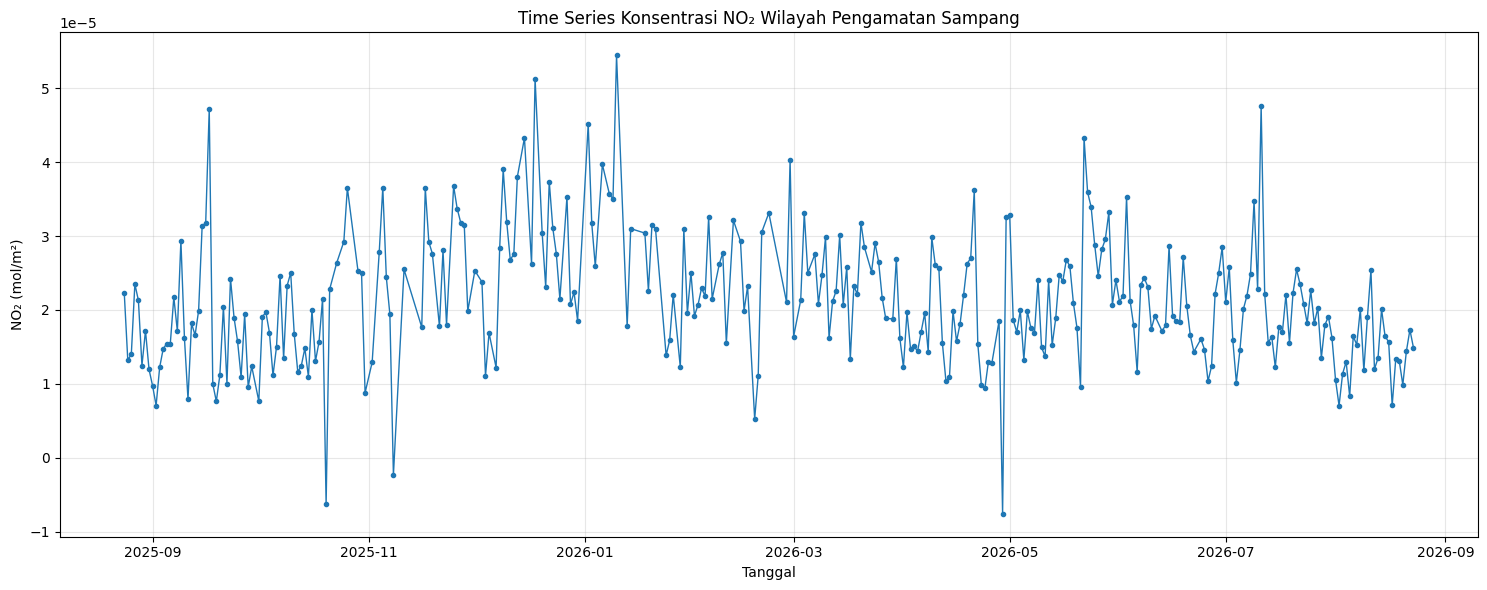

In [37]:
# ============================================
# KODE 34 - VISUALISASI TIME SERIES NO2
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    df["tanggal"],
    df["NO2"],
    marker=".",
    linewidth=1
)

plt.xlabel("Tanggal")
plt.ylabel("NO₂ (mol/m²)")
plt.title(
    "Time Series Konsentrasi NO₂ "
    "Wilayah Pengamatan Sampang"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Penjelasan
Outlier dibedakan menjadi Outlier Tinggi dan Outlier Rendah berdasarkan posisinya terhadap batas IQR.


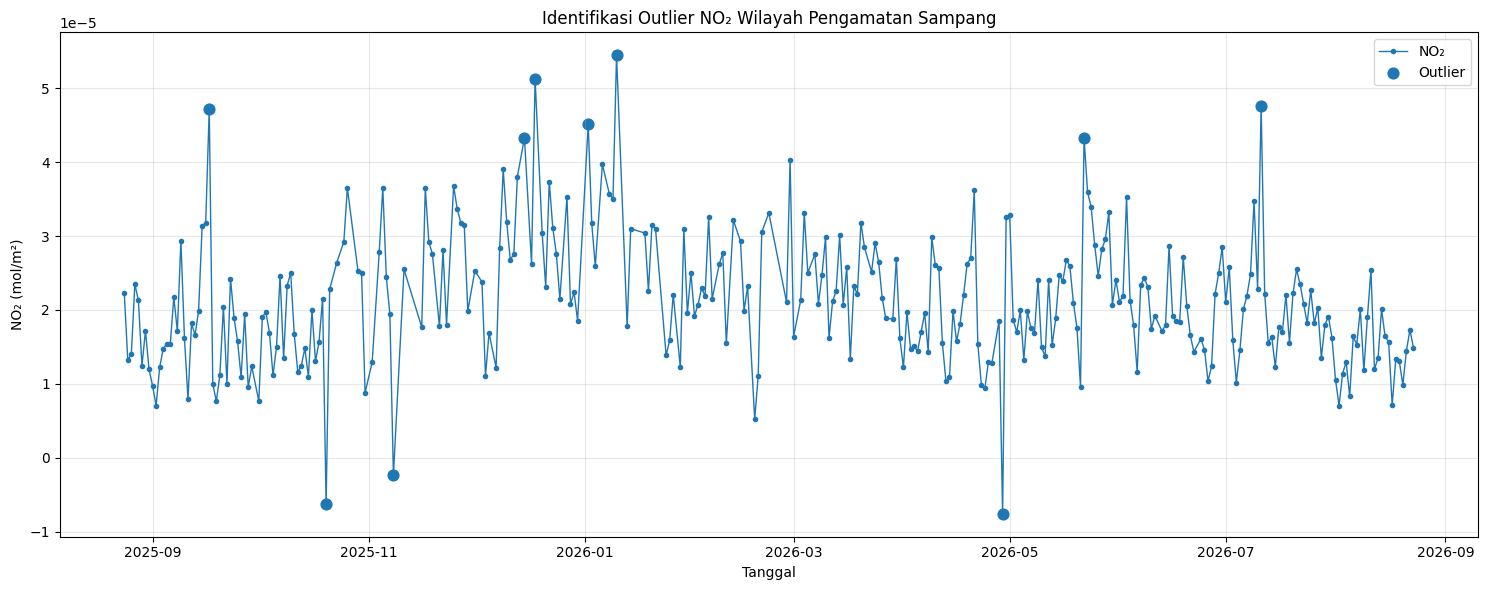

In [38]:
# ============================================
# KODE 35 - VISUALISASI OUTLIER
# ============================================

normal = df[
    df["jenis_outlier"] == "Normal"
]

outlier = df[
    df["jenis_outlier"] != "Normal"
]

plt.figure(figsize=(15, 6))

plt.plot(
    df["tanggal"],
    df["NO2"],
    marker=".",
    linewidth=1,
    label="NO₂"
)

plt.scatter(
    outlier["tanggal"],
    outlier["NO2"],
    s=60,
    label="Outlier"
)

plt.xlabel("Tanggal")
plt.ylabel("NO₂ (mol/m²)")
plt.title(
    "Identifikasi Outlier NO₂ "
    "Wilayah Pengamatan Sampang"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Ringkasan Hasil Pertemuan 1

Berdasarkan output notebook sumber:

- Data yang diminta mencakup periode **24 Agustus 2025–24 Agustus 2026**.
- Hasil akhir memiliki **315 observasi**.
- Tidak terdapat missing value pada kolom `tanggal`, `lat`, `lon`, dan `NO2`.
- Terdapat **51 tanggal tanpa observasi** dari total 366 hari.
- Kelengkapan data adalah **86,07%**.
- Rata-rata NO₂ sekitar **0,000021**.
- Nilai minimum **-0,000008** dan maksimum **0,000054**.
- Dengan metode IQR ditemukan **10 outlier (3,17%)**, terdiri dari **7 outlier tinggi** dan **3 outlier rendah**.

Hasil ini menjadi dasar untuk proses pengolahan dan modifikasi dataset pada pertemuan berikutnya.
